In [4]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

In [5]:
base_path = r"F:\Deep Learning\Neural Networks\Class_imbalance\dataset"

for split in ["train", "test", "val"]:
    for cls in ["class_0", "class_1", "class_2"]:
        os.makedirs(os.path.join(base_path, split, cls), exist_ok=True)

In [6]:
def generate_image(shape, color, path):
    # Create a 512x512 blank image (white background)
    img = np.ones((512, 512, 3), dtype=np.uint8) * 255
    
    # Calculate center and dimensions for 512x512
    center = (256, 256)
    shape_size = 150  # Adjust this to make shapes larger/smaller
    
    if shape == "circle":
        cv2.circle(img, center, shape_size, color, -1)
    elif shape == "square":
        # Calculate square coordinates (centered)
        half_size = shape_size // 2
        top_left = (center[0] - half_size, center[1] - half_size)
        bottom_right = (center[0] + half_size, center[1] + half_size)
        cv2.rectangle(img, top_left, bottom_right, color, -1)
    elif shape == "triangle":
        # Create an equilateral triangle
        height = int(shape_size * np.sqrt(3))
        pt1 = (center[0], center[1] - height // 2)  # Top point
        pt2 = (center[0] - shape_size // 2, center[1] + height // 2)  # Bottom left
        pt3 = (center[0] + shape_size // 2, center[1] + height // 2)  # Bottom right
        triangle_cnt = np.array([pt1, pt2, pt3])
        cv2.drawContours(img, [triangle_cnt], 0, color, -1)
    
    cv2.imwrite(path, img)

In [7]:
# Generate class_0 images (1000 total: 700 train, 150 test, 150 val)
for i in range(700):
    generate_image("circle", (255, 0, 0), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\train\\class_0\\img_{i}.png")

for i in range(700, 850):
    generate_image("circle", (255, 0, 0), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\test\\class_0\\img_{i}.png")

for i in range(850, 1000):
    generate_image("circle", (255, 0, 0), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\val\\class_0\\img_{i}.png")

# Generate class_1 images (100 total: 70 train, 15 test, 15 val)
for i in range(70):
    generate_image("square", (0, 0, 255), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\train\\class_1\\img_{i}.png")

for i in range(70, 85):
    generate_image("square", (0, 0, 255), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\test\\class_1\\img_{i}.png")

for i in range(85, 100):
    generate_image("square", (0, 0, 255), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\val\\class_1\\img_{i}.png")

# Generate class_2 images (choose your desired total number and split)
# Example: 200 total images (140 train, 30 test, 30 val)
for i in range(140):
    generate_image("triangle", (0, 255, 0), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\train\\class_2\\img_{i}.png")

for i in range(140, 170):
    generate_image("triangle", (0, 255, 0), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\test\\class_2\\img_{i}.png")

for i in range(170, 200):
    generate_image("triangle", (0, 255, 0), f"F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\val\\class_2\\img_{i}.png")

In [8]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=r"F:\Deep Learning\Neural Networks\Class_imbalance\dataset\train",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=r"F:\Deep Learning\Neural Networks\Class_imbalance\dataset\test",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=r"F:\Deep Learning\Neural Networks\Class_imbalance\dataset\val",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
print("\n")
print("Training Classes   : ", train_ds.class_names)
print("Test Classes       : ", test_ds.class_names)
print("Validation Classes : ", val_ds.class_names)


Found 910 files belonging to 3 classes.
Found 195 files belonging to 3 classes.
Found 195 files belonging to 3 classes.


Training Classes   :  ['class_0', 'class_1', 'class_2']
Test Classes       :  ['class_0', 'class_1', 'class_2']
Validation Classes :  ['class_0', 'class_1', 'class_2']


In [10]:
class_names = train_ds.class_names

In [11]:
dataset = "F:\\Deep Learning\\Neural Networks\\Class_imbalance\\dataset\\train"

In [12]:
counts = {}
for class_name in class_names:
    class_path = os.path.join(dataset, class_name)
    counts[class_name] = len(os.listdir(class_path))

print("Class distribution:")
for class_name, count in sorted(counts.items()):
    print(f"  {class_name}: {count} images")

Class distribution:
  class_0: 700 images
  class_1: 70 images
  class_2: 140 images


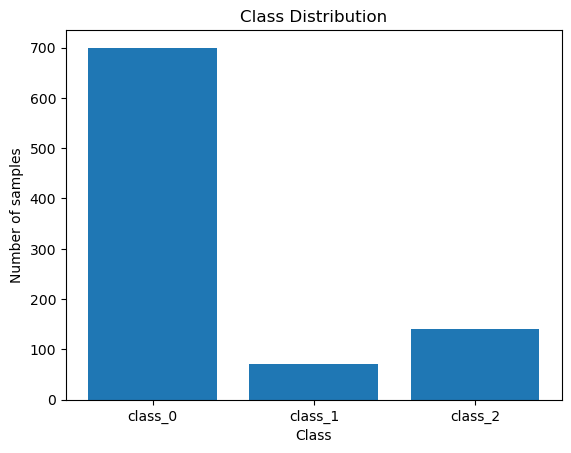

In [13]:
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()

In [22]:
for index, (images, labels) in enumerate(train_ds):
    print(f"Batch -> {index} is loaded with :")
    print(f"Total images and shape : {images.shape}")
    print(f"Total labels shape : {labels.shape}")
    print(f"Labels are : {labels}\n")

Batch -> 0 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [2 0 0 0 2 0 0 0 0 0 2 0 2 0 0 0]

Batch -> 1 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0]

Batch -> 2 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [0 0 2 0 2 0 0 0 0 0 0 0 2 0 0 0]

Batch -> 3 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1]

Batch -> 4 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [0 0 0 0 0 0 0 0 2 0 1 0 1 0 2 0]

Batch -> 5 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [0 0 0 0 0 0 0 2 2 0 0 0 0 0 2 0]

Batch -> 6 is loaded with :
Total images and shape : (16, 224, 224, 3)
Total labels shape : (16,)
Labels are : [2 0 0 2 0 0 

In [26]:
train_labels = []
for images, labels in train_ds:
    train_labels.extend(labels.numpy().tolist())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(zip(class_names, class_weights))

In [27]:
for class_names, class_weights in sorted(class_weight_dict.items()):
    print(f"  {class_names}: {class_weights}")

  a: 2.1666666666666665
  c: 0.43333333333333335
  l: 4.333333333333333
